In [ ]:
# Vulnerability CLassifier (NN): i feel like I would use a normal ANN
# GOAL: Given vulnerability attributes and description predict a CVSS score (float value from 0-10)
# INPUT:
# OUTPUT: value between 0-10
# https://www.kaggle.com/code/cloudnineforreal/cvss-prediction

In [11]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
# import torch
# import torch.nn as nn
# import torch.optim as optim

## Upload/Understand Data

In [2]:
cve_data = pd.read_csv("../data/cve.csv")
cve_data.head()

,Unnamed: 0,mod_date,pub_date,cvss,cwe_code,cwe_name,summary,access_authentication,access_complexity,access_vector,impact_availability,impact_confidentiality,impact_integrity
0,CVE-2019-16548,2019-11-21 15:15:00,2019-11-21 15:15:00,6.8,352,Cross-Site Request Forgery (CSRF),A cross-site request forgery vulnerability in ...,NaN,NaN,NaN,NaN,NaN,NaN
1,CVE-2019-16547,2019-11-21 15:15:00,2019-11-21 15:15:00,4.0,732,Incorrect Permission Assignment for Critical ...,Missing permission checks in various API endpo...,NaN,NaN,NaN,NaN,NaN,NaN
2,CVE-2019-16546,2019-11-21 15:15:00,2019-11-21 15:15:00,4.3,639,Authorization Bypass Through User-Controlled Key,Jenkins Google Compute Engine Plugin 4.1.1 and...,NaN,NaN,NaN,NaN,NaN,NaN
3,CVE-2013-2092,2019-11-20 21:22:00,2019-11-20 21:15:00,4.3,79,Improper Neutralization of Input During Web P...,Cross-site Scripting (XSS) in Dolibarr ERP/CRM...,NaN,NaN,NaN,NaN,NaN,NaN
4,CVE-2013-2091,2019-11-20 20:15:00,2019-11-20 20:15:00,7.5,89,Improper Neutralization of Special Elements u...,SQL injection vulnerability in Dolibarr ERP/CR...,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# drop columns
drop_col = ["Unnamed: 0", "mod_date", "pub_date"]
cve_data.drop(columns=drop_col, inplace=True)

# fill na categorical columns as "UNKNOWN"
catgy_cols = ["access_authentication", "access_complexity", "access_vector", "impact_availability", "impact_confidentiality", "impact_integrity"]
cve_data[catgy_cols] = cve_data[catgy_cols].fillna("UNKNOWN")

# one hot encode categorical columns
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).set_output(transform="pandas")
catgy_encode = ohe.fit_transform(cve_data[catgy_cols])

# combine data
cve_data = pd.concat([cve_data, catgy_encode], axis=1)
cve_data.drop(columns=catgy_cols, inplace=True)

In [4]:
cve_data["summary"]

0        A cross-site request forgery vulnerability in ...
1        Missing permission checks in various API endpo...
2        Jenkins Google Compute Engine Plugin 4.1.1 and...
3        Cross-site Scripting (XSS) in Dolibarr ERP/CRM...
4        SQL injection vulnerability in Dolibarr ERP/CR...
                               ...                        
89655    ** REJECT **  DO NOT USE THIS CANDIDATE NUMBER...
89656    ** REJECT **  DO NOT USE THIS CANDIDATE NUMBER...
89657    ** REJECT **  DO NOT USE THIS CANDIDATE NUMBER...
89658    ** REJECT **  DO NOT USE THIS CANDIDATE NUMBER...
89659    ** REJECT **  DO NOT USE THIS CANDIDATE NUMBER...
Name: summary, Length: 89660, dtype: object

In [5]:
# vectorize summary field
# model = SentenceTransformer("all-MiniLM-L6-v2")  # TRY TO USE SBERT
# embeddings = model.encode(cve_data["summary"])
# embeddings

tfidf_summary = TfidfVectorizer(max_features=500, stop_words="english")
summary_feat = tfidf_summary.fit_transform(cve_data["summary"])
# print(summary_feat[6])
summary_feat_df = pd.DataFrame(
    summary_feat.toarray(),
    columns=[f"tfidf_summary_{i}" for i in range(summary_feat.shape[1])]
)

# combine data
merged_cve_data = pd.concat([cve_data.drop(columns=["summary"]), summary_feat_df], axis=1)

# vectorize cve name field
tfidf_name = TfidfVectorizer(max_features=50, stop_words="english")
cwe_name_feat = tfidf_name.fit_transform(cve_data["cwe_name"])
name_feat_df = pd.DataFrame(
    cwe_name_feat.toarray(),
    columns=[f"tfidf_name_{i}" for i in range(cwe_name_feat.shape[1])]
)

# combine data
merged_cve_data = pd.concat([cve_data.drop(columns=["cwe_name"]), name_feat_df], axis=1)
merged_cve_data.head()

,cvss,cwe_code,summary,access_authentication_MULTIPLE,access_authentication_NONE,access_authentication_SINGLE,access_authentication_UNKNOWN,access_complexity_HIGH,access_complexity_LOW,access_complexity_MEDIUM,...,tfidf_name_40,tfidf_name_41,tfidf_name_42,tfidf_name_43,tfidf_name_44,tfidf_name_45,tfidf_name_46,tfidf_name_47,tfidf_name_48,tfidf_name_49
0,6.8,352,A cross-site request forgery vulnerability in ...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.000000,0.315817,0.00000,0.000000,0.0,0.0,0.000000,0.0,0.000000
1,4.0,732,Missing permission checks in various API endpo...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.0,0.000000
2,4.3,639,Jenkins Google Compute Engine Plugin 4.1.1 and...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.00000,0.000000,0.0,0.0,0.000000,0.0,0.000000
3,4.3,79,Cross-site Scripting (XSS) in Dolibarr ERP/CRM...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.369922,0.345435,0.00000,0.000000,0.0,0.0,0.000000,0.0,0.369922
4,7.5,89,SQL injection vulnerability in Dolibarr ERP/CR...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.000000,0.000000,0.31294,0.673061,0.0,0.0,0.312976,0.0,0.000000


In [16]:
# split train/test
input_cols = merged_cve_data.loc[:, merged_cve_data.columns != "cvss"].columns
# input_cols
X = merged_cve_data[input_cols]
y = merged_cve_data["cvss"]

# drop object columns
X = X.select_dtypes(exclude="object")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

## Model Definition

In [17]:
rfr = RandomForestRegressor(n_estimators=10)
rfr.fit(X_train, y_train)

RandomForestRegressor(n_estimators=10)

In [ ]:
# model metrics
from sklearn.metrics import mean_squared_error, r2_score

# oob = rfr.oob_score_
# print(f"Out of Bag Score: {oob}")

predict = rfr.predict(X_test)
mse = mean_squared_error(y_test, predict)
print(f"MSE: {mse}")

r2 = r2_score(y_test, predict)
print(f"R2 Value: {r2}")

"""TFIDF METRICS
MSE: 0.02974535224109783
R2 Value: 0.9925021166467017
"""


MSE: 0.02974535224109783
R2 Value: 0.9925021166467017


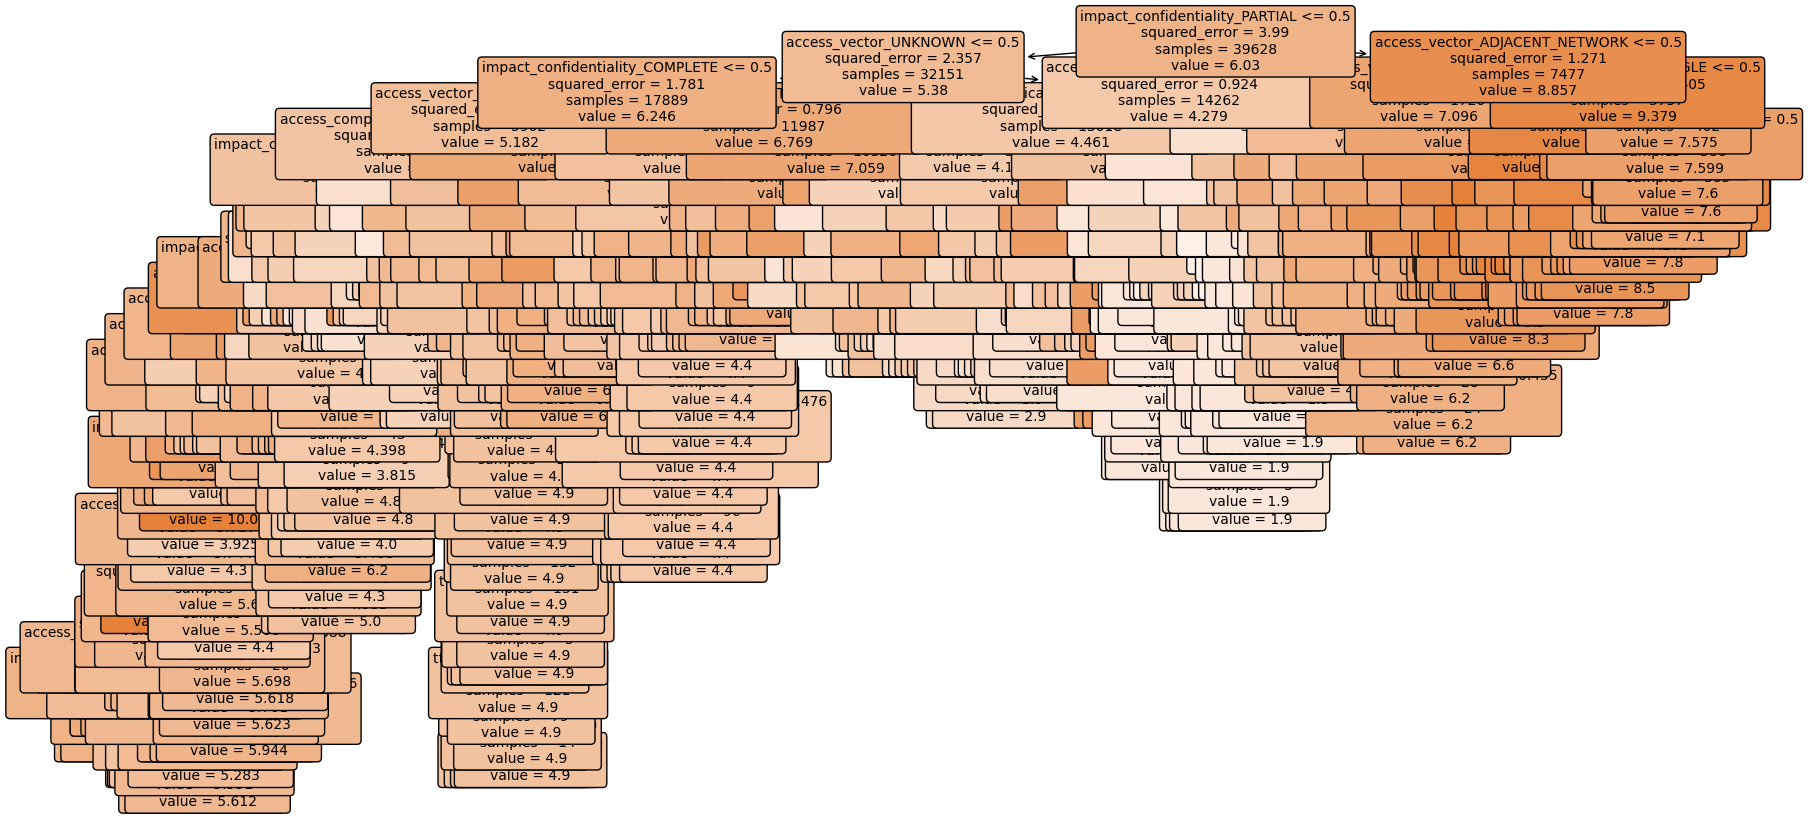

In [ ]:
# visualize RFR
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree_to_plot = rfr.estimators_[0]
plt.figure(figsize=(20,10))
plot_tree(tree_to_plot, feature_names=merged_cve_data.columns.tolist(), filled=True, rounded=True, fontsize=10)
plt.show()